# Text-to-SQL 파인튜닝 프로젝트

> 자연어 질문을 SQL 쿼리로 변환하는 모델을 만든다 — **도메인 특화 파인튜닝**의 첫 실전

02에서 범용 Alpaca 데이터로 학습한 것과 달리,  
이번에는 **특정 태스크(Text→SQL)**에 집중하여 측정 가능한 성능 향상을 노린다.

In [1]:
# === 환경 설치 ===
!pip install datasets transformers peft accelerate trl bitsandbytes matplotlib

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import re
from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU 없음 - 학습 스텝을 줄여서 원리 학습 모드로 진행")

c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 4070 Ti


---
## 1. Text-to-SQL 데이터셋 탐색

자연어 질문 + 테이블 스키마 → SQL 쿼리

In [3]:
# === 데이터셋 로드 ===
# b-mc2/sql-create-context: 자연어 + CREATE TABLE + SQL 쌍

dataset = load_dataset("b-mc2/sql-create-context")
data = dataset['train']

print(f"데이터셋: b-mc2/sql-create-context")
print(f"전체 크기: {len(data):,}개")
print(f"컬럼: {data.column_names}")

print("\n샘플 3개:")
print("=" * 60)
for i in range(3):
    print(f"\n[{i+1}]")
    print(f"  Question: {data[i]['question']}")
    print(f"  Context:  {data[i]['context'][:100]}...")
    print(f"  Answer:   {data[i]['answer']}")

데이터셋: b-mc2/sql-create-context
전체 크기: 78,577개
컬럼: ['answer', 'question', 'context']

샘플 3개:

[1]
  Question: How many heads of the departments are older than 56 ?
  Context:  CREATE TABLE head (age INTEGER)...
  Answer:   SELECT COUNT(*) FROM head WHERE age > 56

[2]
  Question: List the name, born state and age of the heads of departments ordered by age.
  Context:  CREATE TABLE head (name VARCHAR, born_state VARCHAR, age VARCHAR)...
  Answer:   SELECT name, born_state, age FROM head ORDER BY age

[3]
  Question: List the creation year, name and budget of each department.
  Context:  CREATE TABLE department (creation VARCHAR, name VARCHAR, budget_in_billions VARCHAR)...
  Answer:   SELECT creation, name, budget_in_billions FROM department


In [4]:
# === 데이터 분석 ===

# 실습용 서브셋 (전체 78K는 시간이 너무 걸림)
data_subset = data.shuffle(seed=42).select(range(3000))

# SQL 키워드 분포
sql_keywords = []
for i in range(len(data_subset)):
    sql = data_subset[i]['answer'].upper()
    if 'SELECT' in sql: sql_keywords.append('SELECT')
    if 'JOIN' in sql: sql_keywords.append('JOIN')
    if 'GROUP BY' in sql: sql_keywords.append('GROUP BY')
    if 'ORDER BY' in sql: sql_keywords.append('ORDER BY')
    if 'HAVING' in sql: sql_keywords.append('HAVING')
    if 'COUNT' in sql or 'SUM' in sql or 'AVG' in sql:
        sql_keywords.append('집계함수')
    if 'WHERE' in sql: sql_keywords.append('WHERE')
    if 'SUBQUERY' in sql or sql.count('SELECT') > 1:
        sql_keywords.append('서브쿼리')

from collections import Counter
keyword_counts = Counter(sql_keywords)

print("SQL 패턴 분포:")
for kw, count in keyword_counts.most_common():
    pct = count / len(data_subset) * 100
    bar = '█' * int(pct / 2)
    print(f"  {kw:<12} {count:>5} ({pct:>5.1f}%) {bar}")

# 길이 분석
q_lens = [len(data_subset[i]['question']) for i in range(len(data_subset))]
s_lens = [len(data_subset[i]['answer']) for i in range(len(data_subset))]

print(f"\n길이 통계:")
print(f"  Question: 평균 {np.mean(q_lens):.0f}자, 최대 {np.max(q_lens)}자")
print(f"  SQL:      평균 {np.mean(s_lens):.0f}자, 최대 {np.max(s_lens)}자")

SQL 패턴 분포:
  SELECT        3000 (100.0%) ██████████████████████████████████████████████████
  WHERE         2904 ( 96.8%) ████████████████████████████████████████████████
  집계함수           635 ( 21.2%) ██████████
  JOIN            76 (  2.5%) █
  GROUP BY        43 (  1.4%) 
  ORDER BY        30 (  1.0%) 
  서브쿼리            26 (  0.9%) 
  HAVING          17 (  0.6%) 

길이 통계:
  Question: 평균 61자, 최대 201자
  SQL:      평균 77자, 최대 316자


---
## 2. 데이터 전처리 파이프라인

Phase 3에서 배운 정제 + Chat Template 변환을 Text-to-SQL에 적용한다.

In [5]:
# === Text-to-SQL 전용 데이터 전처리 ===

def format_text_to_sql(sample):
    """Text-to-SQL 데이터를 ChatML 형식으로 변환"""
    
    # 시스템 프롬프트: SQL 생성 전문가 역할 부여
    system_msg = "You are a SQL expert. Given a database schema and a natural language question, generate the correct SQL query."
    
    # 유저 메시지: 스키마 + 질문
    user_msg = f"""### Database Schema:\n{sample['context']}\n\n### Question:\n{sample['question']}\n\n### SQL Query:"""
    
    # ChatML 형식
    text = (
        f"<|im_start|>system\n{system_msg}<|im_end|>\n"
        f"<|im_start|>user\n{user_msg}<|im_end|>\n"
        f"<|im_start|>assistant\n{sample['answer']}<|im_end|>"
    )
    return {"text": text}

# 전처리 적용
data_formatted = data_subset.map(format_text_to_sql)

# 길이 필터 (너무 긴 것 제거)
data_formatted = data_formatted.filter(lambda x: len(x['text']) < 2000)

# 분할
split = data_formatted.train_test_split(test_size=0.1, seed=42)
train_data = split['train']
eval_data = split['test']

print(f"Train: {len(train_data)}개")
print(f"Eval:  {len(eval_data)}개")

print(f"\n변환 샘플:")
print("=" * 60)
print(train_data[0]['text'][:500])
print("...")

Train: 2700개
Eval:  300개

변환 샘플:
<|im_start|>system
You are a SQL expert. Given a database schema and a natural language question, generate the correct SQL query.<|im_end|>
<|im_start|>user
### Database Schema:
CREATE TABLE table_name_5 (score VARCHAR, set_3 VARCHAR)

### Question:
What is the score when the set 3 is 26–28?

### SQL Query:<|im_end|>
<|im_start|>assistant
SELECT score FROM table_name_5 WHERE set_3 = "26–28"<|im_end|>
...


---
## 3. 모델 로드 + LoRA 설정

In [6]:
# === 모델 로드 ===

if torch.cuda.is_available():
    model_name = "Qwen/Qwen2.5-1.5B-Instruct"
    
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16,
    )
    model = prepare_model_for_kbit_training(model)
else:
    model_name = "gpt2"
    model = AutoModelForCausalLM.from_pretrained(model_name)

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

print(f"모델: {model_name}")

`torch_dtype` is deprecated! Use `dtype` instead!
Exception in thread Thread-7 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 6: invalid start byte
Loading weights: 100%|██████████| 338/338 [00:01<00:00, 225.16it/s, Materializing param=model.norm.weight]                              


모델: Qwen/Qwen2.5-1.5B-Instruct


In [7]:
# === LoRA 적용 ===

if "qwen" in model_name.lower():
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"]
elif "gpt2" in model_name.lower():
    target_modules = ["c_attn", "c_proj"]
else:
    target_modules = ["q_proj", "v_proj"]

# Text-to-SQL은 구조적 출력이 필요 -> r을 좀 더 높게
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=32,               # 02보다 높은 r: SQL 생성은 정밀도가 중요
    lora_alpha=64,      # alpha = r × 2
    lora_dropout=0.05,
    target_modules=target_modules,
)

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

print(f"\nr=32로 올린 이유:")
print(f"  - SQL은 문법적 정확도가 매우 중요")
print(f"  - SELECT/FROM/WHERE 구조를 정확히 학습하려면 표현력 필요")
print(f"  - 02의 범용 r=16 대비 2배")

trainable params: 36,929,536 || all params: 1,580,643,840 || trainable%: 2.3364

r=32로 올린 이유:
  - SQL은 문법적 정확도가 매우 중요
  - SELECT/FROM/WHERE 구조를 정확히 학습하려면 표현력 필요
  - 02의 범용 r=16 대비 2배


---
## 4. 학습 전 SQL 생성 능력 (Baseline)

In [8]:
# === 학습 전 SQL 생성 테스트 ===

test_cases = [
    {
        "schema": "CREATE TABLE employees (id INT, name VARCHAR, department VARCHAR, salary INT)",
        "question": "Find the average salary for each department",
        "expected": "SELECT department, AVG(salary) FROM employees GROUP BY department",
    },
    {
        "schema": "CREATE TABLE orders (id INT, customer_id INT, amount DECIMAL, order_date DATE)",
        "question": "What is the total order amount for each customer?",
        "expected": "SELECT customer_id, SUM(amount) FROM orders GROUP BY customer_id",
    },
    {
        "schema": "CREATE TABLE products (id INT, name VARCHAR, price DECIMAL, category VARCHAR)",
        "question": "Find all products that cost more than 100 dollars ordered by price",
        "expected": "SELECT * FROM products WHERE price > 100 ORDER BY price",
    },
]

def generate_sql(model, tokenizer, schema, question, max_new_tokens=150):
    """SQL 생성"""
    system_msg = "You are a SQL expert. Given a database schema and a natural language question, generate the correct SQL query."
    user_msg = f"### Database Schema:\n{schema}\n\n### Question:\n{question}\n\n### SQL Query:"
    
    formatted = (
        f"<|im_start|>system\n{system_msg}<|im_end|>\n"
        f"<|im_start|>user\n{user_msg}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )
    
    inputs = tokenizer(formatted, return_tensors="pt")
    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    # SQL만 추출 (첫 번째 줄 또는 세미콜론까지)
    sql = generated.split('\n')[0].strip()
    if '<|im_end|>' in sql:
        sql = sql.split('<|im_end|>')[0].strip()
    return sql

print("학습 전 SQL 생성 (Baseline):")
print("=" * 60)
baseline_results = []
for tc in test_cases:
    pred = generate_sql(peft_model, tokenizer, tc['schema'], tc['question'])
    baseline_results.append(pred)
    print(f"\nQ: {tc['question']}")
    print(f"Expected: {tc['expected']}")
    print(f"Got:      {pred[:200]}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


학습 전 SQL 생성 (Baseline):

Q: Find the average salary for each department
Expected: SELECT department, AVG(salary) FROM employees GROUP BY department
Got:      ```sql

Q: What is the total order amount for each customer?
Expected: SELECT customer_id, SUM(amount) FROM orders GROUP BY customer_id
Got:      ```sql

Q: Find all products that cost more than 100 dollars ordered by price
Expected: SELECT * FROM products WHERE price > 100 ORDER BY price
Got:      ```sql


---
## 5. 학습 실행

In [9]:
# === Training Arguments ===

output_dir = "./output/text_to_sql"

training_args = SFTConfig(
    output_dir=output_dir,
    
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    
    num_train_epochs=3,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    
    fp16=False,
    bf16=torch.cuda.is_available(),
    
    logging_steps=10,
    logging_first_step=True,
    
    save_strategy="epoch",
    eval_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    
    max_length=512,
    dataset_text_field="text",
    
    gradient_checkpointing=True,
    max_grad_norm=1.0,
    report_to="none",
    seed=42,
)

trainer = SFTTrainer(
    model=peft_model,
    processing_class=tokenizer,
    train_dataset=train_data,
    eval_dataset=eval_data,
    args=training_args,
)

print("Text-to-SQL 학습 시작...")
result = trainer.train()
print(f"\n완료! 스텝: {result.global_step}, Loss: {result.training_loss:.4f}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Truncating eval dataset: 100%|██████████| 300/300 [00:00<00:00, 17065.51 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Text-to-SQL 학습 시작...


Epoch,Training Loss,Validation Loss
1,0.583784,0.598308
2,0.520067,0.582516
3,0.441896,0.604455



완료! 스텝: 507, Loss: 0.5366


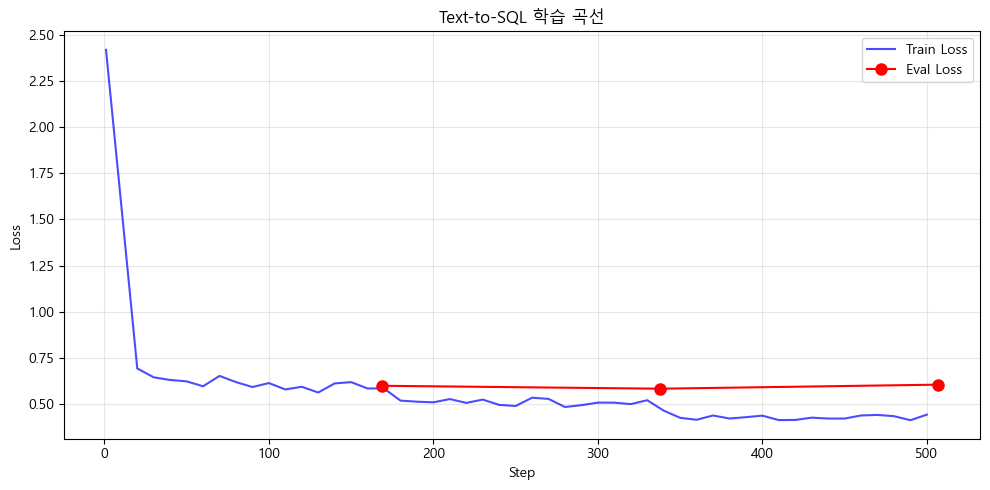

In [10]:
# === Loss 시각화 ===

log_history = trainer.state.log_history
train_losses = [(log['step'], log['loss']) for log in log_history if 'loss' in log]
eval_losses = [(log['step'], log['eval_loss']) for log in log_history if 'eval_loss' in log]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

if train_losses:
    steps, losses = zip(*train_losses)
    ax.plot(steps, losses, 'b-', alpha=0.7, label='Train Loss')

if eval_losses:
    eval_steps, eval_loss_vals = zip(*eval_losses)
    ax.plot(eval_steps, eval_loss_vals, 'ro-', label='Eval Loss', markersize=8)

ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Text-to-SQL 학습 곡선')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. 학습 후 SQL 생성 및 평가

In [11]:
# === 학습 후 SQL 생성 ===

peft_model.eval()

print("Before vs After SQL 생성 비교:")
print("=" * 60)

after_results = []
for i, tc in enumerate(test_cases):
    pred = generate_sql(peft_model, tokenizer, tc['schema'], tc['question'])
    after_results.append(pred)
    
    print(f"\n{'─' * 60}")
    print(f"Q: {tc['question']}")
    print(f"Expected: {tc['expected']}")
    print(f"Before:   {baseline_results[i][:150]}")
    print(f"After:    {pred[:150]}")

Before vs After SQL 생성 비교:

────────────────────────────────────────────────────────────
Q: Find the average salary for each department
Expected: SELECT department, AVG(salary) FROM employees GROUP BY department
Before:   ```sql
After:    SELECT AVG(salary), department FROM employees GROUP BY department

────────────────────────────────────────────────────────────
Q: What is the total order amount for each customer?
Expected: SELECT customer_id, SUM(amount) FROM orders GROUP BY customer_id
Before:   ```sql
After:    SELECT SUM(amount), customer_id FROM orders GROUP BY customer_id

────────────────────────────────────────────────────────────
Q: Find all products that cost more than 100 dollars ordered by price
Expected: SELECT * FROM products WHERE price > 100 ORDER BY price
Before:   ```sql
After:    SELECT * FROM products WHERE price > 100 ORDER BY price


In [12]:
# === SQL 정확도 평가 (간이) ===
# 실전에서는 실제 DB에서 쿼리 실행하여 결과 비교 (Execution Accuracy)
# 여기서는 문자열 유사도 + 키워드 매칭으로 간이 평가

def evaluate_sql(predicted, expected):
    """간이 SQL 평가: 키워드 매칭 + 정규화 비교"""
    # SQL 정규화: 소문자 + 공백 통일
    def normalize(sql):
        sql = sql.upper().strip()
        sql = re.sub(r'\s+', ' ', sql)
        sql = sql.replace(';', '')
        return sql
    
    pred_norm = normalize(predicted)
    exp_norm = normalize(expected)
    
    scores = {}
    
    # 1) 정확 일치
    scores['exact_match'] = pred_norm == exp_norm
    
    # 2) 키워드 포함 여부
    keywords = ['SELECT', 'FROM', 'WHERE', 'GROUP BY', 'ORDER BY', 'JOIN', 'HAVING']
    exp_keywords = [kw for kw in keywords if kw in exp_norm]
    pred_keywords = [kw for kw in keywords if kw in pred_norm]
    
    if exp_keywords:
        matched = sum(1 for kw in exp_keywords if kw in pred_keywords)
        scores['keyword_recall'] = matched / len(exp_keywords)
    else:
        scores['keyword_recall'] = 1.0
    
    # 3) 테이블/컬럼 이름 포함 여부
    # expected에서 테이블/컬럼 이름 추출 (간이)
    exp_words = set(exp_norm.split()) - set(keywords) - {'*', ',', '(', ')', 'AND', 'OR', 'AS', 'ON', 'BY', 'DESC', 'ASC', 'INT', 'VARCHAR'}
    if exp_words:
        matched = sum(1 for w in exp_words if w in pred_norm)
        scores['entity_recall'] = matched / len(exp_words)
    else:
        scores['entity_recall'] = 1.0
    
    # 종합 점수
    scores['total'] = (scores['keyword_recall'] * 0.4 + 
                       scores['entity_recall'] * 0.4 + 
                       (1.0 if scores['exact_match'] else 0.0) * 0.2)
    
    return scores

# eval 데이터 일부로 평가
print("Eval 데이터 평가 (상위 50개):")
print("=" * 60)

n_eval = min(50, len(eval_data))
scores_list = []

for i in range(n_eval):
    sample = data_subset[eval_data[i]['__index_level_0__']] if '__index_level_0__' in eval_data.column_names else eval_data[i]
    
    # 원본 데이터에서 question, context, answer 가져오기
    # formatted 데이터에서 원본 필드 접근
    schema = sample.get('context', '')
    question = sample.get('question', '')
    expected = sample.get('answer', '')
    
    if not schema or not question or not expected:
        continue
    
    pred = generate_sql(peft_model, tokenizer, schema, question)
    scores = evaluate_sql(pred, expected)
    scores_list.append(scores)

if scores_list:
    avg_scores = {
        'exact_match': np.mean([s['exact_match'] for s in scores_list]),
        'keyword_recall': np.mean([s['keyword_recall'] for s in scores_list]),
        'entity_recall': np.mean([s['entity_recall'] for s in scores_list]),
        'total': np.mean([s['total'] for s in scores_list]),
    }
    
    print(f"\n평가 결과 ({len(scores_list)}개 샘플):")
    for metric, value in avg_scores.items():
        print(f"  {metric:<20}: {value:.3f}")
    
    print(f"\n참고: 실전 평가 방법")
    print(f"  1. Execution Accuracy: DB에서 실행하여 결과 일치 여부")
    print(f"  2. Spider/BIRD 벤치마크: 표준 Text-to-SQL 벤치마크")
    print(f"  3. LLM-as-Judge: GPT-4로 SQL 정확도 판정")

Eval 데이터 평가 (상위 50개):

평가 결과 (50개 샘플):
  exact_match         : 0.720
  keyword_recall      : 0.990
  entity_recall       : 0.978
  total               : 0.931

참고: 실전 평가 방법
  1. Execution Accuracy: DB에서 실행하여 결과 일치 여부
  2. Spider/BIRD 벤치마크: 표준 Text-to-SQL 벤치마크
  3. LLM-as-Judge: GPT-4로 SQL 정확도 판정


---
## 7. 어댑터 저장

In [13]:
# === Text-to-SQL 어댑터 저장 ===

import os

adapter_path = "./output/text_to_sql/final_adapter"
peft_model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

total_size = sum(os.path.getsize(os.path.join(adapter_path, f)) 
                for f in os.listdir(adapter_path))

print(f"어댑터 저장: {adapter_path}")
print(f"크기: {total_size / (1024**2):.1f} MB")
print(f"\n이 어댑터를 원본 모델에 붙이면 Text-to-SQL 전문 모델이 된다.")
print(f"같은 원본 모델에 다른 어댑터를 붙이면 다른 태스크 전문 모델.")
print(f"-> 하나의 모델로 여러 태스크를 다루는 효율적 구조")

어댑터 저장: ./output/text_to_sql/final_adapter
크기: 151.8 MB

이 어댑터를 원본 모델에 붙이면 Text-to-SQL 전문 모델이 된다.
같은 원본 모델에 다른 어댑터를 붙이면 다른 태스크 전문 모델.
-> 하나의 모델로 여러 태스크를 다루는 효율적 구조


---
## 8. 02 vs 03 비교: 범용 vs 도메인 특화

02에서의 범용 학습과 이번 도메인 특화 학습의 차이를 정리한다.

In [14]:
# === 범용 vs 도메인 특화 비교 ===

print("범용 파인튜닝 vs 도메인 특화 파인튜닝:")
print("=" * 60)
print(f"""
{'항목':<16} {'02: 범용 (Alpaca)':<25} {'03: Text-to-SQL':<25}
{'─'*16} {'─'*25} {'─'*25}
{'데이터':<16} {'Alpaca (다양한 태스크)':<25} {'SQL 전용 데이터셋':<25}
{'데이터 수':<16} {'~500개':<25} {'~3,000개':<25}
{'LoRA r':<16} {'16':<25} {'32':<25}
{'학습 목표':<16} {'일반 지시 따르기':<25} {'SQL 문법 + 스키마 이해':<25}
{'평가 방법':<16} {'정성적 비교':<25} {'키워드/실행 정확도':<25}
{'실용성':<16} {'범용 챗봇':<25} {'DB 쿼리 자동화':<25}
""")

print("핵심 교훈:")
print("  1. 도메인 특화 데이터가 소량이라도 범용 데이터 대량보다 효과적")
print("  2. 태스크 복잡도에 맞게 r(rank)을 조절해야 함")
print("  3. 평가 기준이 명확할수록 개선 방향이 분명해짐")
print("  4. 프롬프트 형식(시스템 메시지 포함)이 성능에 큰 영향")

범용 파인튜닝 vs 도메인 특화 파인튜닝:

항목               02: 범용 (Alpaca)           03: Text-to-SQL          
──────────────── ───────────────────────── ─────────────────────────
데이터              Alpaca (다양한 태스크)          SQL 전용 데이터셋              
데이터 수            ~500개                     ~3,000개                  
LoRA r           16                        32                       
학습 목표            일반 지시 따르기                 SQL 문법 + 스키마 이해          
평가 방법            정성적 비교                    키워드/실행 정확도               
실용성              범용 챗봇                     DB 쿼리 자동화                

핵심 교훈:
  1. 도메인 특화 데이터가 소량이라도 범용 데이터 대량보다 효과적
  2. 태스크 복잡도에 맞게 r(rank)을 조절해야 함
  3. 평가 기준이 명확할수록 개선 방향이 분명해짐
  4. 프롬프트 형식(시스템 메시지 포함)이 성능에 큰 영향


---
## 정리

| 단계 | 내용 | 핵심 |
|------|------|------|
| **데이터** | b-mc2/sql-create-context | 스키마+질문 → SQL |
| **전처리** | 시스템 프롬프트 + 스키마 구조화 | 형식이 성능을 좌우 |
| **LoRA** | r=32, alpha=64 | 구조적 출력에 맞게 r 상향 |
| **학습** | 3 epoch, cosine schedule | 02와 동일한 학습 프레임워크 |
| **평가** | 키워드 매칭 + 엔티티 추출 | 실전은 실행 정확도(Execution Accuracy) |

### 다음: 04_학습_분석과_최적화.ipynb

- 하이퍼파라미터 튜닝 (r, lr, epoch 비교)
- Unsloth로 학습 속도 2배 향상
- 모델을 HuggingFace Hub에 업로드